# PCA on embeddings, with randomly picked spots (for reconstruction)

Same steps as `pca_on_embeddings.ipynb`, with one change:

**`pca_on_embeddings.ipynb` used the *first* 250 spots in the file. This notebook picks 250 spots at *random* from the whole slide.**

Why: the patches file stores spots in grid order, so the first 250 are one strip along the slide's edge (lots of blank background).
The learning curve in `pca_reconstruction.ipynb` showed that more variety in the training spots helps reconstruction.
Random spots cover every tissue type on the slide, so the PCs should describe new spots better.

Everything else is identical: genbio-pathfm embedding, StandardScaler + PCA fit on train only, same plots, same saved file format.

Outputs are saved under a different name (`TENX95_random250_...`) so they don't overwrite the first-250 results.
To run `pca_reconstruction.ipynb` on these results, change its `sample_id` to `"TENX95_random250"`.

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Mac fix: conda (numpy/scikit-learn) and pip (PyTorch) each bring their own copy of
# the OpenMP library. Two copies running many threads at once crash the kernel.
# Using one thread avoids the crash. The heavy work runs on the Mac GPU anyway.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # allow the two copies to load (safe with 1 thread)

from pathlib import Path

if Path.cwd().stem == "notebooks":
    os.chdir(Path.cwd().parent)
print("Working folder:", os.getcwd())

Working folder: /Users/jk/JHU/BDD/Code


**Mac install:** PyTorch should come from conda (`conda install -c conda-forge pytorch torchvision`), not pip. Mixing the two crashes the kernel on a Mac, so the next cell is commented out.

In [ ]:
# Already installed in the bdd env (PyTorch via conda). Don't pip-install torch here:
# it would bring back the second OpenMP copy that crashed the kernel.
# %pip install -q torch torchvision transformers anndata h5py scikit-learn matplotlib pandas pillow

In [2]:
import torch  # import torch first, before scikit-learn (Mac OpenMP fix)
import glob
import h5py
import anndata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

## Settings

- `sample_id`: which HEST sample to use
- `MAX_SPOTS`: how many spots to pick at random. `None` = use every spot (~11,800 for TENX95)
- `SEED`: controls the random pick. Same seed = same 250 spots every time you run it
- `N_GENES`: how many genes to keep as targets. HEST uses the 50 most variable genes
- `N_PCS`: how many principal components to keep. HEST uses 256
- `run_name`: used in every saved file name, so this run doesn't overwrite the first-250 run

In [3]:
sample_id = "TENX95"
MAX_SPOTS = 250  # change this for future usage (None = use every spot; needs a GPU or a lot of time)
N_GENES = 50
N_PCS = 256
TEST_FRACTION = 0.2
SEED = 0

patches_path = f"hest_data/patches/{sample_id}.h5"
st_path = f"hest_data/st/{sample_id}.h5ad"

if MAX_SPOTS is None:
    run_name = f"{sample_id}_all"
else:
    run_name = f"{sample_id}_random{MAX_SPOTS}"

os.makedirs("outputs/embeddings", exist_ok=True)
os.makedirs("outputs/pca", exist_ok=True)
embedding_path = f"outputs/embeddings/{run_name}_genbio-pathfm.npz"
print("Run name:", run_name)

Run name: TENX95_random250


## 1. Pick random spots and load their patches

First we read only the `coords` (small) to count how many spots the slide has.
Then we pick `MAX_SPOTS` of them at random and read only those patches.

The picked positions are sorted (smallest to largest) because `h5py` can only read rows in increasing order.
Sorting doesn't change *which* spots are picked.

The patches file has three things:
- `img`: the 224×224×3 H&E picture for each spot
- `barcode`: the spot's ID (this is how we find its gene expression)
- `coords`: where the spot sits on the slide

In [4]:
with h5py.File(patches_path, "r") as f:
    all_coords = f["coords"][:]
    n_total = len(all_coords)

    if MAX_SPOTS is None or MAX_SPOTS >= n_total:
        picked = np.arange(n_total)
        imgs = f["img"][:]
        coords = f["coords"][:]
        raw_barcodes = f["barcode"][:]
    else:
        rng = np.random.default_rng(SEED)
        picked = rng.choice(n_total, size=MAX_SPOTS, replace=False)
        picked = np.sort(picked)
        imgs = f["img"][picked]
        coords = f["coords"][picked]
        raw_barcodes = f["barcode"][picked]

barcodes = []
for b in raw_barcodes:
    if hasattr(b, "ravel"):
        b = b.ravel()[0]
    if isinstance(b, bytes):
        b = b.decode()
    barcodes.append(b)
barcodes = np.array(barcodes)

print("Spots on the slide:", n_total)
print("Spots picked:", len(picked))
print("Patches:", imgs.shape)
print("First barcodes:", barcodes[:3])

Spots on the slide: 7592
Spots picked: 250
Patches: (250, 224, 224, 3)
First barcodes: ['007x021' '007x040' '008x036']


### Check: where are the picked spots?

Grey = every spot on the slide. Red = the spots we picked.
The red dots should be spread over the whole tissue, not bunched in one strip like the first 250 were.

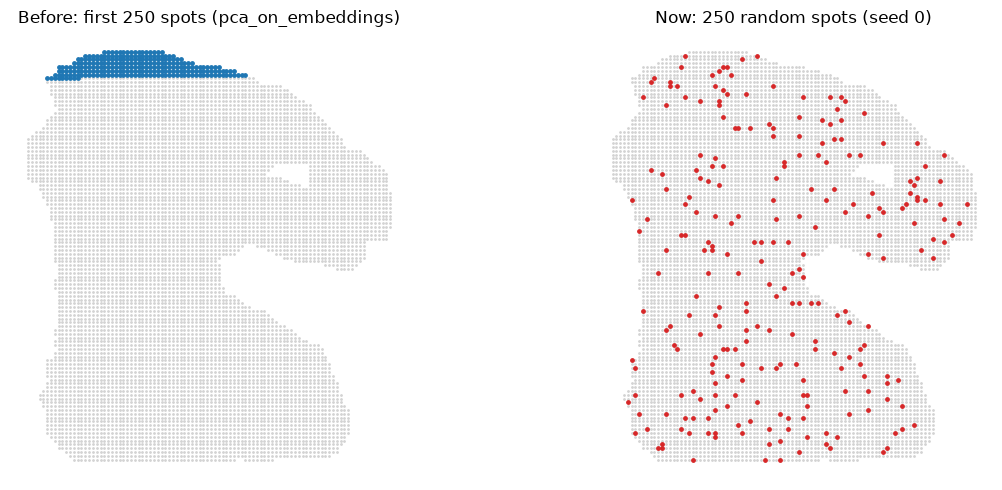

In [5]:
first_250 = all_coords[:250]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(all_coords[:, 0], all_coords[:, 1], s=1, color="lightgrey")
axes[0].scatter(first_250[:, 0], first_250[:, 1], s=6, color="tab:blue")
axes[0].set_title("Before: first 250 spots (pca_on_embeddings)")

axes[1].scatter(all_coords[:, 0], all_coords[:, 1], s=1, color="lightgrey")
axes[1].scatter(coords[:, 0], coords[:, 1], s=6, color="tab:red")
axes[1].set_title(f"Now: {len(picked)} random spots (seed {SEED})")

for ax in axes:
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"outputs/pca/{run_name}_picked_spots.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Embed every patch with genbio-pathfm

This uses the same model and the same `transform` as `Foundationmodel_test.ipynb`.
The difference is that we loop over all patches in batches (16 at a time) instead of one image.

On a Mac it uses the built-in GPU (`mps`). If you get an error that mentions MPS, change the device to `torch.device("cpu")`; with 250 spots that's slower but still workable.
The first run also downloads the model weights (several GB) from Hugging Face, so expect a wait before progress lines appear.

Embedding takes a long time, so the result is saved to `outputs/embeddings/`.
If that file already exists, this cell just loads it and skips the model entirely.
(`outputs/` is in `.gitignore`, so the file stays on your computer.)

The file name includes `run_name`, so it won't load the first-250 embeddings by mistake.
If you change `SEED`, delete the saved file so it gets recomputed.

In [6]:
if os.path.exists(embedding_path):
    saved = np.load(embedding_path, allow_pickle=True)
    embeddings = saved["embeddings"]
    saved_barcodes = saved["barcodes"]
    print("Loaded saved embeddings:", embeddings.shape)

else:
    import torch
    from PIL import Image
    from torchvision import transforms
    from transformers import AutoModel

    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print("Using:", device, flush=True)

    print("Loading model (first time downloads several GB)...", flush=True)

    model = AutoModel.from_pretrained("genbio-ai/genbio-pathfm", trust_remote_code=True)
    model = model.to(device)
    model.eval()
    print("Model loaded.", flush=True)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.697, 0.575, 0.728),
            std=(0.188, 0.240, 0.187),
        ),
    ])

    batch_size = 4  # change this for future usage (64 is fine on an NVIDIA GPU)
    all_embeddings = []

    for start in range(0, len(imgs), batch_size):
        batch_imgs = imgs[start:start + batch_size]

        batch_tensors = []
        for img in batch_imgs:
            pil_img = Image.fromarray(img).convert("RGB")
            batch_tensors.append(transform(pil_img))
        x = torch.stack(batch_tensors).to(device)

        with torch.inference_mode():
            out = model(x)

        all_embeddings.append(out.float().cpu().numpy())

        if (start // batch_size) % 10 == 0:
            print(f"{start + len(batch_imgs)} / {len(imgs)} patches done", flush=True)

    embeddings = np.concatenate(all_embeddings, axis=0)
    saved_barcodes = barcodes

    np.savez(embedding_path, embeddings=embeddings, barcodes=saved_barcodes)
    print("Saved:", embedding_path, embeddings.shape)

Using: mps
Loading model (first time downloads several GB)...
Model loaded.
4 / 250 patches done
44 / 250 patches done
84 / 250 patches done
124 / 250 patches done
164 / 250 patches done
204 / 250 patches done
244 / 250 patches done
Saved: outputs/embeddings/TENX95_random250_genbio-pathfm.npz (250, 4608)


In [7]:
assert len(saved_barcodes) == len(barcodes) and np.all(saved_barcodes == barcodes), \
    "Saved embeddings don't match these patches. Delete the saved file and re-run the cell above."

print("Embeddings:", embeddings.shape)

Embeddings: (250, 4608)


## 3. Load the gene expression and line it up with the patches

The expression table (`.h5ad`) is spots × genes. Its rows are not guaranteed to be in the same order as the patches,
so we reorder it using the barcodes. After this, row `i` of `embeddings` and row `i` of `expr` are the same spot.

Then:
- **log1p**: raw counts are very skewed (a few spots have huge counts), so we use log(1 + count), like HEST does
- **top 50 most variable genes**: genes that barely change across spots are not interesting to predict

In [8]:
adata = anndata.read_h5ad(st_path)
print("Expression table:", adata.shape, "(spots x genes)")

keep = np.isin(barcodes, adata.obs_names)
print("Patches with a matching expression row:", keep.sum(), "/", len(barcodes))

embeddings = embeddings[keep]
coords = coords[keep]
barcodes = barcodes[keep]

adata = adata[barcodes]

counts = adata.X
if hasattr(counts, "toarray"):
    counts = counts.toarray()
counts = np.asarray(counts, dtype=np.float32)

log_expr = np.log1p(counts)

gene_variance = log_expr.var(axis=0)
top_gene_idx = np.argsort(gene_variance)[::-1][:N_GENES]
gene_names = np.array(adata.var_names)[top_gene_idx]

expr = log_expr[:, top_gene_idx]

print("X (embeddings):", embeddings.shape)
print("y (expression):", expr.shape)
print("Top 10 genes:", list(gene_names[:10]))

Expression table: (11845, 541) (spots x genes)
Patches with a matching expression row: 250 / 250
X (embeddings): (250, 4608)
y (expression): (250, 50)
Top 10 genes: ['MYBPC1', 'ABCC11', 'FOXA1', 'MLPH', 'PGR', 'SFRP4', 'KRT14', 'SERPINA3', 'AGR3', 'S100A14']


## 4. Split spots into train and test

For now this is a **random spot split** inside one slide.

This is the "leaky" setting your project is designed to measure: neighboring spots look alike and have similar expression,
so a test spot often has a near-twin in the training set. Later, with more samples downloaded,
the split should be by **slide/patient** instead, and you compare the two.

In [9]:
spot_index = np.arange(len(barcodes))

train_idx, test_idx = train_test_split(
    spot_index, test_size=TEST_FRACTION, random_state=SEED
)

X_train = embeddings[train_idx]
X_test = embeddings[test_idx]
y_train = expr[train_idx]
y_test = expr[test_idx]

print("Train spots:", len(train_idx))
print("Test spots:", len(test_idx))

Train spots: 200
Test spots: 50


## 5. StandardScaler + PCA (fit on train only)

This is the same pipeline as the HEST benchmark code:

```python
Pipeline([("scaler", StandardScaler()), ("PCA", PCA(n_components=256))])
```

- `fit_transform(X_train)`: learns the mean/SD of each of the 4608 embedding numbers **and** finds the PCs, using train spots only, then projects the train spots
- `transform(X_test)`: projects the test spots onto those same PCs. Nothing about the test spots is used to find the PCs

If you fit on all spots instead, test spots would help choose the PCs. That is a small data leak.

PCA can't have more PCs than samples. With `MAX_SPOTS = 250` there are 200 training spots, so you'll get 200 PCs instead of 256. That's expected, and it goes back to 256 when you use all spots.

In [10]:
n_components = min(N_PCS, X_train.shape[0], X_train.shape[1])

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components, random_state=SEED)),
])

X_train_pca = pipe.fit_transform(X_train)
X_test_pca = pipe.transform(X_test)

pca = pipe.named_steps["pca"]

print("Before PCA:", X_train.shape)
print("After PCA (train):", X_train_pca.shape)
print("After PCA (test):", X_test_pca.shape)
print(f"Variance kept by {n_components} PCs: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

Before PCA: (200, 4608)
After PCA (train): (200, 200)
After PCA (test): (50, 200)
Variance kept by 200 PCs: 100.0%


## 6. Scree plot

Left: the share of variance each of the first 20 PCs explains (like the StatQuest scree plot).
Right: the running total over all kept PCs. This shows how much of the original 4608-number embedding the 256 PCs keep.

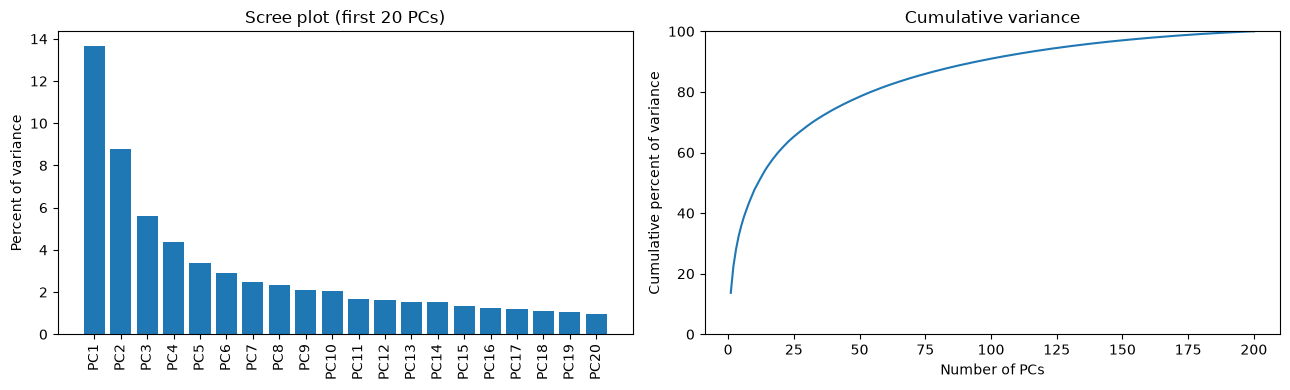

First 1 PCs: 13.7%
First 2 PCs: 22.4%
First 10 PCs: 47.7%
First 50 PCs: 78.4%
First 200 PCs: 100.0%


In [11]:
per_pc = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(per_pc)

n_show = min(20, len(per_pc))
labels = ["PC" + str(i + 1) for i in range(n_show)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(labels, per_pc[:n_show])
axes[0].set_ylabel("Percent of variance")
axes[0].set_title("Scree plot (first 20 PCs)")
axes[0].tick_params(axis="x", rotation=90)

axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative)
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative percent of variance")
axes[1].set_title("Cumulative variance")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"outputs/pca/{run_name}_scree.png", dpi=150, bbox_inches="tight")
plt.show()

for k in [1, 2, 10, 50, len(cumulative)]:
    print(f"First {k} PCs: {cumulative[k - 1]:.1f}%")

## 7. PCA plot, colored by a gene

Each dot is a training spot, placed by its PC1 and PC2 scores.
The color is the (log1p) expression of the most variable gene.

If the colors form a smooth gradient across the plot, the image embedding already "sees" something related to that gene.
That's a good sign for the ridge regression step.

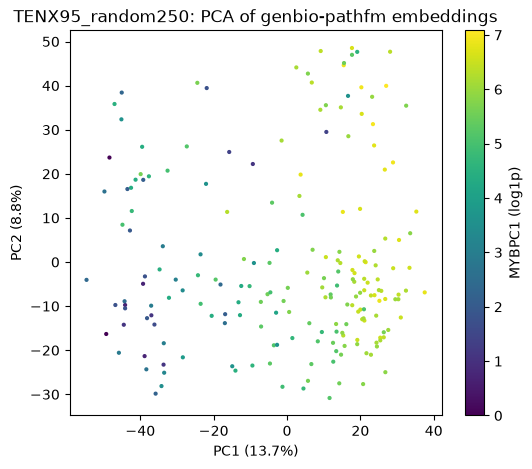

In [12]:
gene_to_color = gene_names[0]
gene_col = list(gene_names).index(gene_to_color)

plt.figure(figsize=(6, 5))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=y_train[:, gene_col], s=4, cmap="viridis")
plt.colorbar(label=f"{gene_to_color} (log1p)")
plt.xlabel(f"PC1 ({per_pc[0]:.1f}%)")
plt.ylabel(f"PC2 ({per_pc[1]:.1f}%)")
plt.title(f"{run_name}: PCA of genbio-pathfm embeddings")
plt.savefig(f"outputs/pca/{run_name}_pc1_pc2_{gene_to_color}.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. PC1 on the tissue

Here every spot (train and test) is drawn at its real position on the slide, colored by its PC1 score.
The gene expression next to it is the same gene as above.

If the two maps show similar regions, PC1 is picking up tissue structure (e.g. tumor vs stroma) that also drives expression.
The y-axis is flipped so the picture matches the slide (image coordinates start at the top).

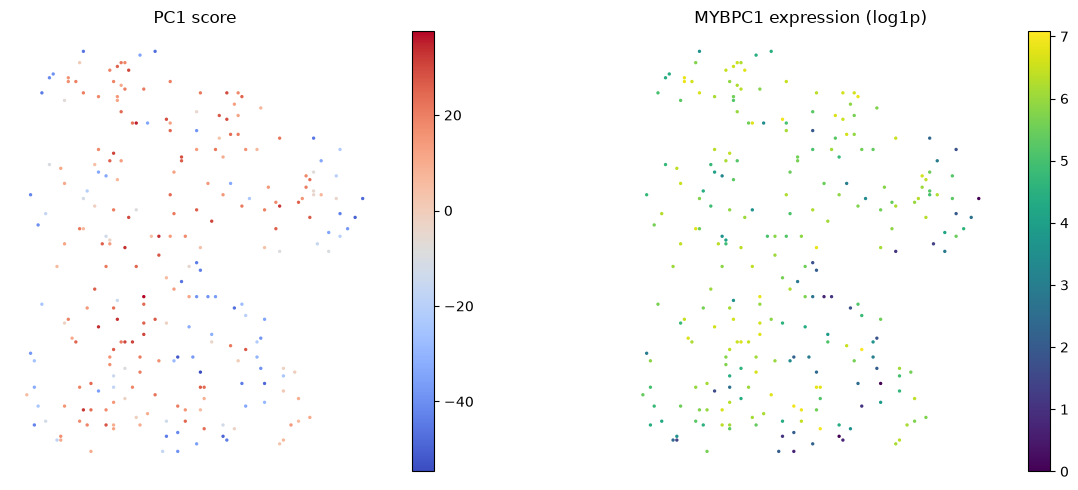

In [13]:
all_pca = pipe.transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=all_pca[:, 0], s=2, cmap="coolwarm")
axes[0].set_title("PC1 score")
fig.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=expr[:, gene_col], s=2, cmap="viridis")
axes[1].set_title(f"{gene_to_color} expression (log1p)")
fig.colorbar(sc1, ax=axes[1])

for ax in axes:
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"outputs/pca/{run_name}_pc1_on_tissue.png", dpi=150, bbox_inches="tight")
plt.show()

### Why we don't look at loading scores here

In the StatQuest video, the loading scores told us which **genes** mattered most for PC1.
Here, the loading scores are over the 4608 **embedding numbers**, which don't have a human meaning
(there is no "embedding feature #1712 = nuclei size"). So the loadings aren't useful to read.
The PCA plots and the ridge results are what we interpret instead.

## 9. Save the PCA features

Saved as `outputs/pca/<run_name>_pca<k>.npz` (for example `TENX95_random250_pca200.npz`).

To measure reconstruction on this run, open `pca_reconstruction.ipynb` and change one line:

```python
sample_id = "TENX95_random250"
```

Then compare its test R² with the first-250 run (0.72 with 200 PCs).

In [14]:
out_path = f"outputs/pca/{run_name}_pca{n_components}.npz"

np.savez(
    out_path,
    X_train_pca=X_train_pca,
    X_test_pca=X_test_pca,
    y_train=y_train,
    y_test=y_test,
    gene_names=gene_names,
    train_barcodes=barcodes[train_idx],
    test_barcodes=barcodes[test_idx],
    train_coords=coords[train_idx],
    test_coords=coords[test_idx],
)
print("Saved:", out_path)

Saved: outputs/pca/TENX95_random250_pca200.npz
